# Auto-Encoder L1 Training

Train cluster-specific auto-encoders for anomaly detection using L1 company-level metrics.

**Workflow:**
1. Load L1 metrics from OpenSearch for specific entities
2. Feature selection and preprocessing
3. Train auto-encoder (PyTorch)
4. Evaluate and calculate anomaly thresholds
5. Save model and artifacts

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import json
import pickle
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

from opensearchpy import OpenSearch
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 5070


## 2. Configuration

**Edit these parameters for your training run:**

In [2]:
# ========== CONFIGURATION ==========

# OpenSearch connection
ES_HOST = "https://100.125.228.80:9200"
ES_USER = "admin"
ES_PASSWORD = "SecretPassword"

# Data parameters
WINDOW_SIZE = 60  # 60, 30, or 10 minutes
INDEX_PATTERN = f"metrics-l1-{WINDOW_SIZE}m*"

# Entity IDs (companies in this cluster)
ENTITY_IDS_FILE = "../../03-Clusters/cluster0_entities.csv"  # CSV with company_id column
# Or define manually:
# ENTITY_IDS = [123, 456, 789]  # Uncomment to use manual list

# Time ranges (ISO 8601 UTC)
TRAIN_START = "2025-08-01T00:00:00"
TRAIN_END = "2025-09-30T00:00:00"
TEST_START = "2025-10-01T00:00:00"
TEST_END = "2025-11-30T00:00:00"

# Model parameters
MODEL_NAME = "cluster0-60m"  # e.g., "cluster0-60m", "cluster1-30m"
ENCODING_DIM = 12  # Bottleneck dimension
HIDDEN_DIM = 30    # Hidden layer dimension

# Training parameters
BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 100
VALIDATION_SPLIT = 0.2  # 20% of training data for validation

# Output directory
OUTPUT_DIR = Path("out")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device (GPU/CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")


Using device: cuda


## 3. Feature Selection

Define L1 features to use for anomaly detection (exclude L2 user-level features).

In [3]:
# L1 Company-level features (47 features)
FEATURE_LIST = [
    # Temporal Volume (7)
    'total_requests',
    'mean_requests_per_minute',
    'max_requests_per_minute',
    'std_requests_per_minute',
    'cv_request_rate',
    'peak_to_average_ratio',
    'burst_score',
    
    # Status Distribution (8)
    'pct_2xx_responses',
    'pct_3xx_responses',
    'pct_4xx_responses',
    'pct_5xx_responses',
    'error_rate',
    'critical_error_rate',
    'status_code_entropy',
    'unique_status_codes',
    
    # Performance (9)
    'mean_response_time',
    'std_response_time',
    'p50_response_time',
    'p75_response_time',
    'p90_response_time',
    'p95_response_time',
    'p99_response_time',
    'pct_slow_requests',
    'pct_very_slow_requests',
    
    # Entity Profiling (5)
    'unique_source_ips',
    'mean_requests_per_ip',
    'max_requests_single_ip',
    'gini_ip_distribution',
    'ip_concentration_top10pct',
    
    # API Usage (7)
    'unique_api_modules',
    'module_entropy',
    'top_module_percentage',
    'module_switching_frequency',
    'unique_routes',
    'route_entropy',
    'top5_routes_percentage',
    
    # Payload (4)
    'mean_response_size',
    'std_response_size',
    'max_response_size',
    'min_response_size',
    
    # Client Diversity (3)
    'unique_user_agents',
    'user_agent_entropy',
    'bot_like_ua_percentage',
    
    # Request Patterns (3)
    'unique_http_methods',
    'get_request_ratio',
    'post_request_ratio',
]

print(f"Total features: {len(FEATURE_LIST)}")

Total features: 46


## 4. Data Loading from OpenSearch

In [4]:
def get_es_client():
    """Create OpenSearch client."""
    client = OpenSearch(
        hosts=[ES_HOST],
        http_auth=(ES_USER, ES_PASSWORD),
        verify_certs=False,
        ssl_assert_hostname=False,
        ssl_show_warn=False,
        timeout=60,
    )
    if not client.ping():
        raise ConnectionError("Failed to connect to OpenSearch")
    return client

def load_entity_ids(filepath=None, manual_ids=None):
    """Load entity IDs from CSV or use manual list."""
    if manual_ids:
        return manual_ids
    
    df = pd.read_csv(filepath)
    if 'company_id' not in df.columns:
        raise ValueError("CSV must have 'company_id' column")
    
    return df['company_id'].unique().tolist()

def fetch_metrics(client, entity_ids, start_time, end_time, index_pattern):
    """
    Fetch L1 metrics from OpenSearch for specified entities and time range.
    Returns DataFrame with metrics.
    """
    print(f"Fetching metrics from {index_pattern}...")
    print(f"  Entities: {len(entity_ids)}")
    print(f"  Time range: {start_time} to {end_time}")
    
    query = {
        "query": {
            "bool": {
                "must": [
                    {
                        "range": {
                            "@timestamp": {
                                "gte": start_time,
                                "lt": end_time
                            }
                        }
                    },
                    {
                        "terms": {
                            "company_id": entity_ids
                        }
                    }
                ]
            }
        },
        "_source": ["@timestamp", "company_id", "metrics"]
    }
    
    # Scroll through all results
    response = client.search(
        index=index_pattern,
        body=query,
        size=10000,
        scroll='5m'
    )
    
    scroll_id = response.get('_scroll_id')
    hits = response['hits']['hits']
    all_hits = hits.copy()
    
    with tqdm(total=response['hits']['total']['value'], desc="Fetching") as pbar:
        pbar.update(len(hits))
        
        while scroll_id and len(hits) > 0:
            response = client.scroll(scroll_id=scroll_id, scroll='5m')
            scroll_id = response.get('_scroll_id')
            hits = response['hits']['hits']
            all_hits.extend(hits)
            pbar.update(len(hits))
    
    if not all_hits:
        print("WARNING: No documents found!")
        return pd.DataFrame()
    
    # Parse to DataFrame
    data = []
    for hit in all_hits:
        source = hit['_source']
        row = {
            'timestamp': source['@timestamp'],
            'company_id': source['company_id'],
        }
        # Flatten metrics
        if 'metrics' in source:
            row.update(source['metrics'])
        data.append(row)
    
    df = pd.DataFrame(data)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    print(f"Loaded {len(df)} records for {df['company_id'].nunique()} entities")
    return df

In [5]:
# Connect to OpenSearch
es_client = get_es_client()
print("Connected to OpenSearch successfully")

Connected to OpenSearch successfully


In [6]:
# Load entity IDs
try:
    entity_ids = load_entity_ids(ENTITY_IDS_FILE)
except:
    # Fallback to manual list if file doesn't exist
    print(f"Could not load {ENTITY_IDS_FILE}, using ENTITY_IDS variable...")
    entity_ids = ENTITY_IDS  # Define this in config cell if using manual

print(f"Loaded {len(entity_ids)} entity IDs")
print(f"Sample IDs: {entity_ids[:5]}")

Loaded 1 entity IDs
Sample IDs: [436]


In [7]:
# Fetch training data
df_train = fetch_metrics(es_client, entity_ids, TRAIN_START, TRAIN_END, INDEX_PATTERN)

Fetching metrics from metrics-l1-60m*...
  Entities: 1
  Time range: 2025-08-01T00:00:00 to 2025-09-30T00:00:00


Fetching:   0%|          | 0/1272 [00:00<?, ?it/s]

Loaded 1272 records for 1 entities


In [8]:
# Fetch test data
df_test = fetch_metrics(es_client, entity_ids, TEST_START, TEST_END, INDEX_PATTERN)

Fetching metrics from metrics-l1-60m*...
  Entities: 1
  Time range: 2025-10-01T00:00:00 to 2025-11-30T00:00:00


Fetching:   0%|          | 0/659 [00:00<?, ?it/s]

Loaded 659 records for 1 entities


## 5. Data Exploration & Preprocessing

In [9]:
# Check data shape
print("Training data:")
print(f"  Shape: {df_train.shape}")
print(f"  Entities: {df_train['company_id'].nunique()}")
print(f"  Time range: {df_train['timestamp'].min()} to {df_train['timestamp'].max()}")

print("\nTest data:")
print(f"  Shape: {df_test.shape}")
print(f"  Entities: {df_test['company_id'].nunique()}")
print(f"  Time range: {df_test['timestamp'].min()} to {df_test['timestamp'].max()}")

# Display sample
df_train.head()

Training data:
  Shape: (1272, 54)
  Entities: 1
  Time range: 2025-08-06 01:00:00+00:00 to 2025-09-29 23:00:00+00:00

Test data:
  Shape: (659, 54)
  Entities: 1
  Time range: 2025-10-01 00:00:00+00:00 to 2025-11-01 00:00:00+00:00


,timestamp,company_id,burst_score,mean_requests_per_minute,min_requests_per_minute,top5_routes_percentage,ip_concentration_top10pct,critical_error_rate,http11_ratio,p75_response_time,...,pct_slow_requests,unique_operators,module_switching_frequency,p95_response_time,top_module_percentage,std_response_size,p99_response_time,unique_user_agents,mean_response_time,p90_response_time
0,2025-08-28 21:00:00+00:00,436,3,141.616667,5.0,39.684595,0.601742,0.0,1.0,0.34000,...,5.013534,120,0.693539,1.00220,24.161469,127907.152061,3.95508,10,0.408826,0.6490
1,2025-08-28 22:00:00+00:00,436,5,51.550000,1.0,50.695118,0.600065,0.0,1.0,0.45700,...,8.988038,83,0.702231,2.35640,21.112189,22802.788687,3.92128,7,0.592279,0.8434
2,2025-08-28 23:00:00+00:00,436,1,44.400000,0.0,57.169670,0.540541,0.0,1.0,0.52050,...,12.012012,55,0.695195,3.81010,31.831832,80477.403583,8.19621,7,0.780414,1.3455
3,2025-08-29 00:00:00+00:00,436,3,63.683333,1.0,58.989793,0.663177,0.0,1.0,0.60800,...,13.399634,64,0.645643,3.85700,35.985344,132083.110500,5.00460,6,0.749501,2.2970
4,2025-08-29 01:00:00+00:00,436,1,69.133333,3.0,61.234330,0.681774,0.0,1.0,0.47425,...,4.122469,56,0.687801,0.87165,26.060752,33062.365836,2.02484,6,0.392632,0.6793


In [10]:
# Check for missing features
missing_features = [f for f in FEATURE_LIST if f not in df_train.columns]
if missing_features:
    print(f"WARNING: Missing features: {missing_features}")
    # Remove from feature list
    FEATURE_LIST = [f for f in FEATURE_LIST if f in df_train.columns]
    print(f"Using {len(FEATURE_LIST)} available features")

# Extract feature columns
X_train_raw = df_train[FEATURE_LIST].copy()
X_test_raw = df_test[FEATURE_LIST].copy()

print(f"Feature matrix shape: {X_train_raw.shape}")

Feature matrix shape: (1272, 46)


In [11]:
# Check for NaNs and Infs
print("Missing values per feature:")
nan_counts = X_train_raw.isnull().sum()
if nan_counts.sum() > 0:
    print(nan_counts[nan_counts > 0])
    print("\nFilling NaNs with 0...")
    X_train_raw = X_train_raw.fillna(0)
    X_test_raw = X_test_raw.fillna(0)
else:
    print("No missing values")

# Replace infinities
X_train_raw = X_train_raw.replace([np.inf, -np.inf], 0)
X_test_raw = X_test_raw.replace([np.inf, -np.inf], 0)

Missing values per feature:
unique_api_modules             5
module_entropy                 5
top_module_percentage         22
module_switching_frequency     5
unique_routes                 38
route_entropy                 38
top5_routes_percentage        38
dtype: int64

Filling NaNs with 0...


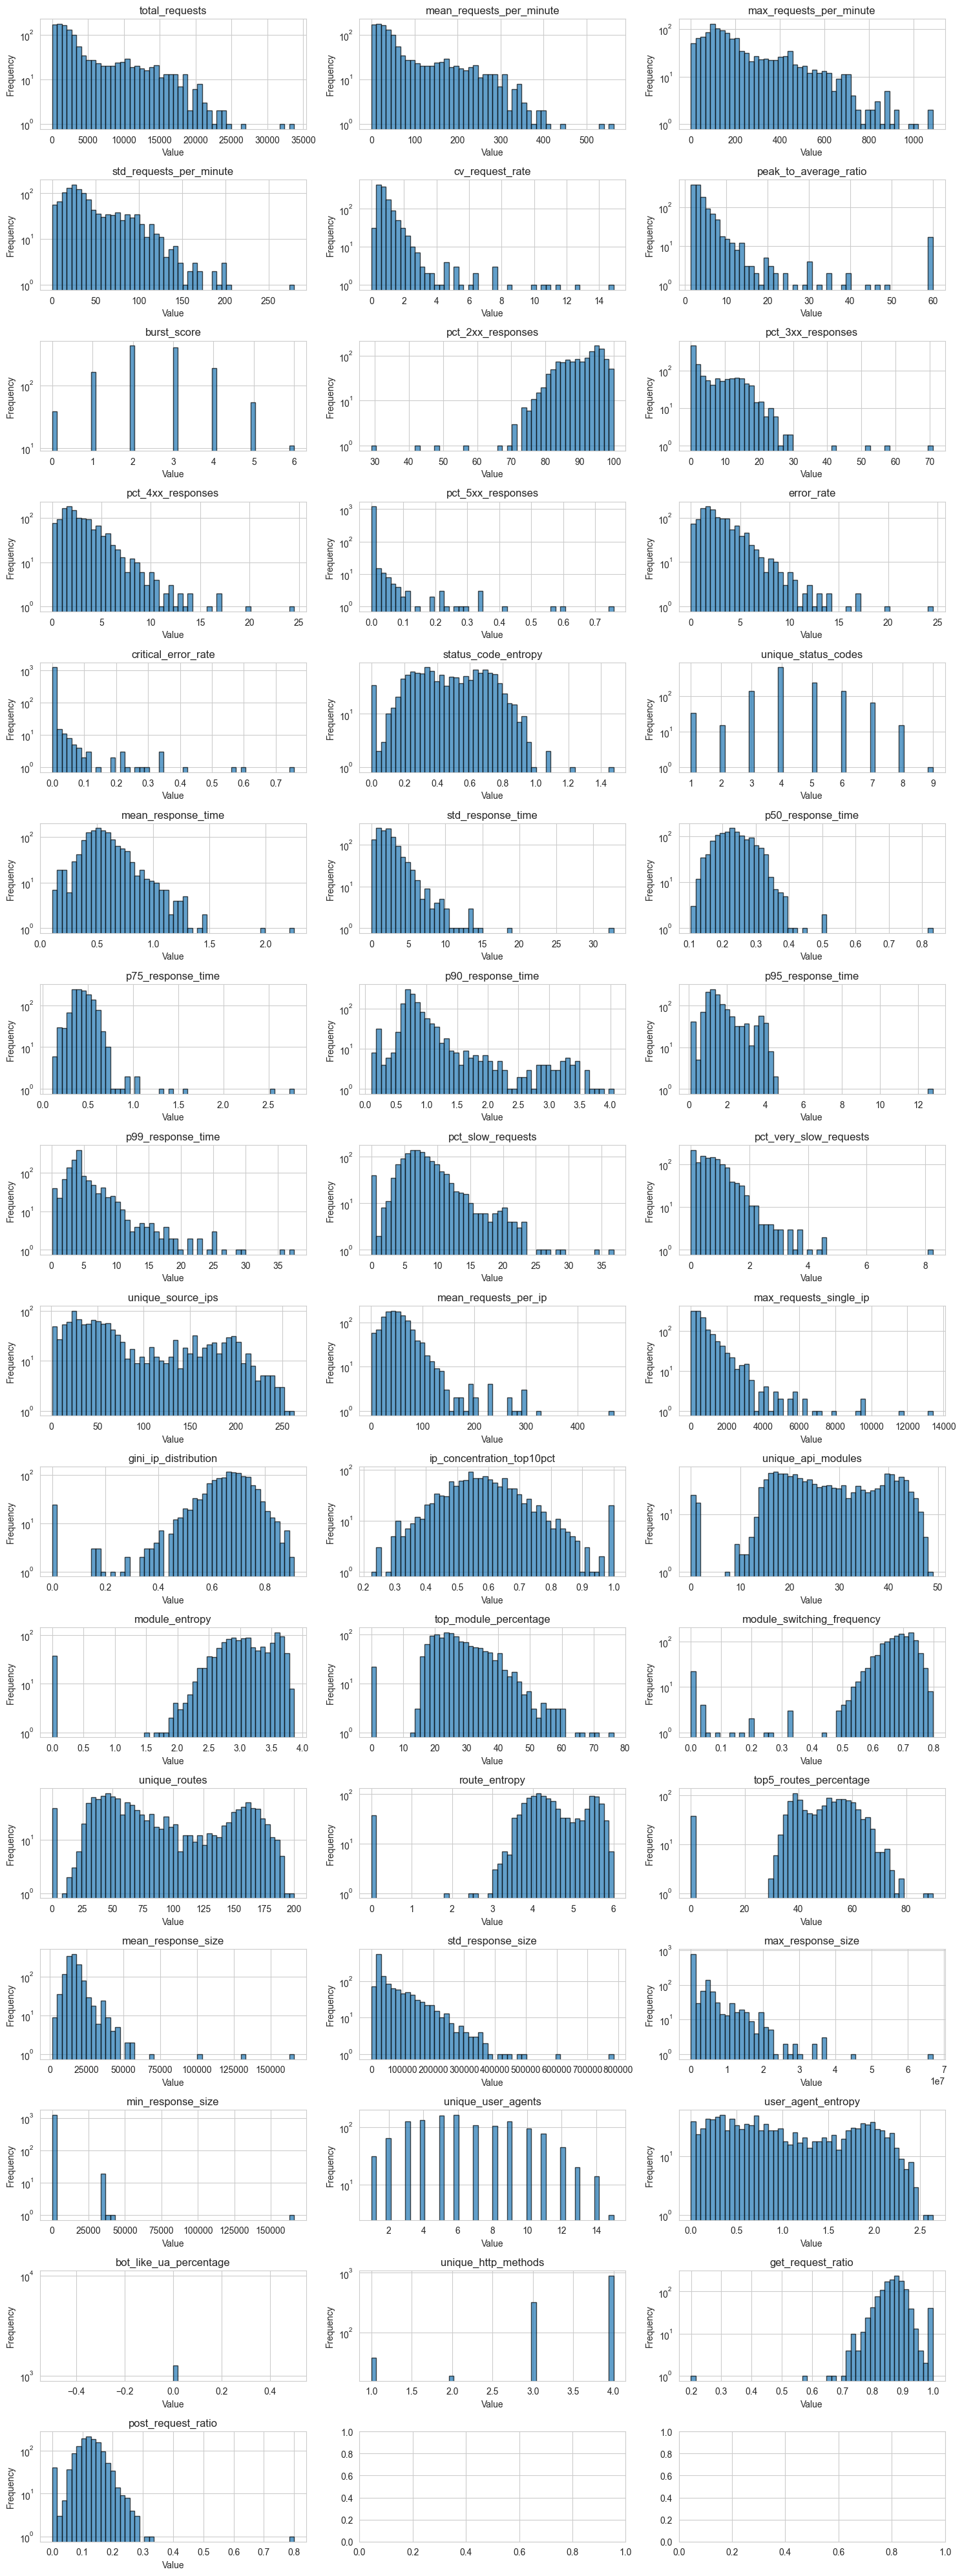

Feature distributions saved


In [12]:
# Feature distributions (sample)
fig, axes = plt.subplots(16, 3, figsize=(15, 40))
axes = axes.flatten()

sample_features = FEATURE_LIST[:46]  # First 9 features
for i, feat in enumerate(sample_features):
    axes[i].hist(X_train_raw[feat], bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_yscale('log')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_feature_distributions.png", dpi=300)
plt.show()

print("Feature distributions saved")

In [13]:
# Normalization (MinMaxScaler for auto-encoders)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Scaled training data: {X_train_scaled.shape}")
print(f"Scaled test data: {X_test_scaled.shape}")
print(f"Value range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

Scaled training data: (1272, 46)
Scaled test data: (659, 46)
Value range: [0.000, 1.000]


In [14]:
# Train/Validation split
X_train, X_val = train_test_split(
    X_train_scaled, 
    test_size=VALIDATION_SPLIT, 
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test_scaled)}")

Training samples: 1017
Validation samples: 255
Test samples: 659


## 6. Model Architecture

In [15]:
class AutoEncoder(nn.Module):
    """Auto-encoder for anomaly detection."""
    
    def __init__(self, input_dim, encoding_dim=12, hidden_dim=30):
        super(AutoEncoder, self).__init__()
        
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        
        # Encoder: input -> hidden -> encoding
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, encoding_dim),
            nn.ReLU(),
        )
        
        # Decoder: encoding -> hidden -> output
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_dim, input_dim),
            # No activation - continuous values
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        """Get encoded representation."""
        return self.encoder(x)
    
    def reconstruction_error(self, x):
        """Calculate MSE reconstruction error per sample."""
        reconstructed = self.forward(x)
        mse = torch.mean((x - reconstructed) ** 2, dim=1)
        return mse


# Initialize model
input_dim = len(FEATURE_LIST)
model = AutoEncoder(
    input_dim=input_dim,
    encoding_dim=ENCODING_DIM,
    hidden_dim=HIDDEN_DIM
).to(DEVICE)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=46, out_features=30, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=30, out_features=12, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=30, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=30, out_features=46, bias=True)
  )
)

Total parameters: 3,718


## 7. Training

In [16]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train).to(DEVICE)
X_val_tensor = torch.FloatTensor(X_val).to(DEVICE)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(DEVICE)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows, 4 for Linux
)

print(f"Batches per epoch: {len(train_loader)}")

Batches per epoch: 4


In [17]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

In [18]:
# Training loop
history = {
    'train_loss': [],
    'val_loss': [],
}

best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 15

print("Starting training...\n")

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for batch_x, _ in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_x)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # Validation phase
    model.eval()
    with torch.no_grad():
        val_reconstructed = model(X_val_tensor)
        val_loss = criterion(val_reconstructed, X_val_tensor).item()
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), OUTPUT_DIR / f"{MODEL_NAME}_best.pth")
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - "
              f"Train Loss: {train_loss:.6f} - "
              f"Val Loss: {val_loss:.6f} - "
              f"Best: {best_val_loss:.6f}")
    
    # Early stopping check
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.6f}")

# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / f"{MODEL_NAME}_best.pth"))
print("Loaded best model")

Starting training...

Epoch [1/100] - Train Loss: 0.584822 - Val Loss: 0.195421 - Best: 0.195421
Epoch [10/100] - Train Loss: 0.271525 - Val Loss: 0.145987 - Best: 0.145987
Epoch [20/100] - Train Loss: 0.168724 - Val Loss: 0.118087 - Best: 0.118087
Epoch [30/100] - Train Loss: 0.109771 - Val Loss: 0.069037 - Best: 0.069037
Epoch [40/100] - Train Loss: 0.065112 - Val Loss: 0.028969 - Best: 0.028969
Epoch [50/100] - Train Loss: 0.041611 - Val Loss: 0.012573 - Best: 0.012573
Epoch [60/100] - Train Loss: 0.033340 - Val Loss: 0.009069 - Best: 0.009069
Epoch [70/100] - Train Loss: 0.027001 - Val Loss: 0.008366 - Best: 0.008366
Epoch [80/100] - Train Loss: 0.023596 - Val Loss: 0.008011 - Best: 0.007981
Epoch [90/100] - Train Loss: 0.020486 - Val Loss: 0.007694 - Best: 0.007694
Epoch [100/100] - Train Loss: 0.018825 - Val Loss: 0.007544 - Best: 0.007453

Training complete!
Best validation loss: 0.007453
Loaded best model


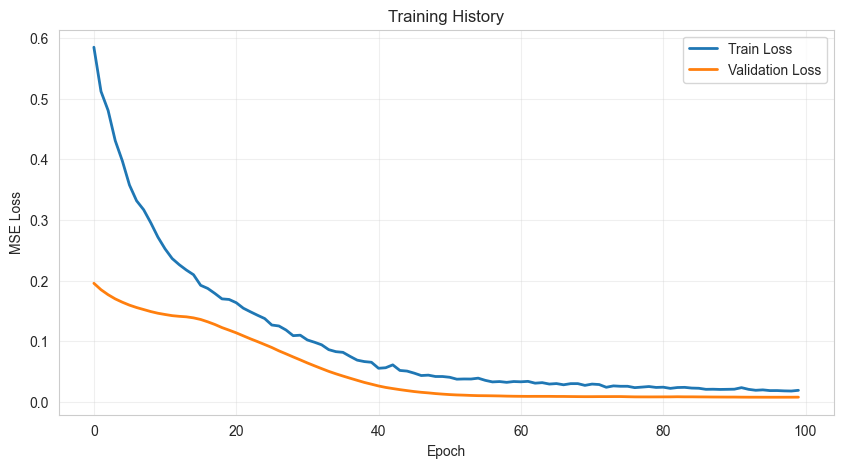

In [19]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_training_history.png", dpi=150)
plt.show()

## 8. Evaluation & Threshold Calculation

In [20]:
# Calculate reconstruction errors
model.eval()
with torch.no_grad():
    train_errors = model.reconstruction_error(X_train_tensor).cpu().numpy()
    val_errors = model.reconstruction_error(X_val_tensor).cpu().numpy()
    test_errors = model.reconstruction_error(X_test_tensor).cpu().numpy()

print("Reconstruction Errors:")
print(f"  Training: mean={train_errors.mean():.6f}, std={train_errors.std():.6f}")
print(f"  Validation: mean={val_errors.mean():.6f}, std={val_errors.std():.6f}")
print(f"  Test: mean={test_errors.mean():.6f}, std={test_errors.std():.6f}")

Reconstruction Errors:
  Training: mean=0.006382, std=0.006257
  Validation: mean=0.007453, std=0.007412
  Test: mean=0.007432, std=0.022733


In [21]:
# Calculate thresholds from validation set
threshold_p90 = np.percentile(val_errors, 90)
threshold_p95 = np.percentile(val_errors, 95)
threshold_p99 = np.percentile(val_errors, 99)
threshold_3sigma = val_errors.mean() + 3 * val_errors.std()

thresholds = {
    'p90': float(threshold_p90),
    'p95': float(threshold_p95),
    'p99': float(threshold_p99),
    '3sigma': float(threshold_3sigma),
    'mean': float(val_errors.mean()),
    'std': float(val_errors.std()),
}

print("\nAnomaly Thresholds (from validation set):")
for name, value in thresholds.items():
    if name not in ['mean', 'std']:
        pct = (val_errors > value).mean() * 100
        print(f"  {name}: {value:.6f} ({pct:.1f}% flagged as anomaly)")


Anomaly Thresholds (from validation set):
  p90: 0.013778 (10.2% flagged as anomaly)
  p95: 0.022073 (5.1% flagged as anomaly)
  p99: 0.042810 (1.2% flagged as anomaly)
  3sigma: 0.029690 (3.1% flagged as anomaly)


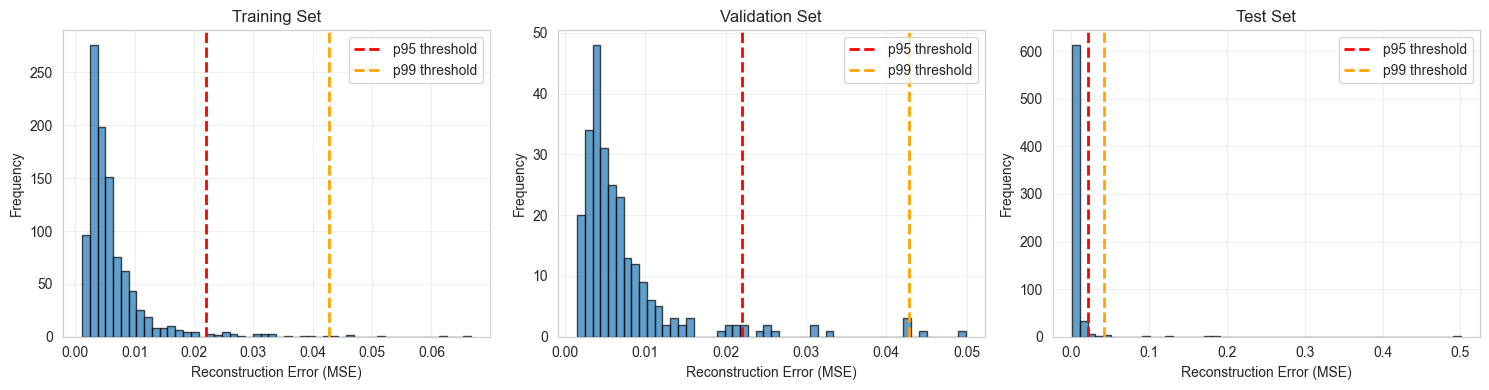

In [22]:
# Visualization: Reconstruction error distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, errors, title in zip(axes, 
                              [train_errors, val_errors, test_errors],
                              ['Training', 'Validation', 'Test']):
    ax.hist(errors, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(threshold_p95, color='red', linestyle='--', linewidth=2, label='p95 threshold')
    ax.axvline(threshold_p99, color='orange', linestyle='--', linewidth=2, label='p99 threshold')
    ax.set_xlabel('Reconstruction Error (MSE)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title} Set')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{MODEL_NAME}_reconstruction_errors.png", dpi=150)
plt.show()

In [23]:
# Test set anomaly rate at different thresholds
print("\nTest set anomaly rates:")
for name, threshold in thresholds.items():
    if name not in ['mean', 'std']:
        anomaly_rate = (test_errors > threshold).mean() * 100
        print(f"  {name}: {anomaly_rate:.2f}%")


Test set anomaly rates:
  p90: 4.40%
  p95: 1.82%
  p99: 0.91%
  3sigma: 1.37%


## 9. Save Model & Artifacts

In [24]:
# Save model (final version)
torch.save(model.state_dict(), OUTPUT_DIR / f"{MODEL_NAME}.pth")
print(f"Model saved: {MODEL_NAME}.pth")

# Save scaler
with open(OUTPUT_DIR / f"{MODEL_NAME}_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved: {MODEL_NAME}_scaler.pkl")

# Save feature list
with open(OUTPUT_DIR / f"{MODEL_NAME}_features.json", 'w') as f:
    json.dump(FEATURE_LIST, f, indent=2)
print(f"Features saved: {MODEL_NAME}_features.json")

# Save thresholds
with open(OUTPUT_DIR / f"{MODEL_NAME}_thresholds.json", 'w') as f:
    json.dump(thresholds, f, indent=2)
print(f"Thresholds saved: {MODEL_NAME}_thresholds.json")

# Save training metadata
metadata = {
    'model_name': MODEL_NAME,
    'window_size': WINDOW_SIZE,
    'train_period': {'start': TRAIN_START, 'end': TRAIN_END},
    'test_period': {'start': TEST_START, 'end': TEST_END},
    'num_entities': len(entity_ids),
    'num_features': len(FEATURE_LIST),
    'encoding_dim': ENCODING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs_trained': len(history['train_loss']),
    'best_val_loss': float(best_val_loss),
    'final_train_loss': float(history['train_loss'][-1]),
    'final_val_loss': float(history['val_loss'][-1]),
    'trained_at': datetime.now().isoformat(),
}

with open(OUTPUT_DIR / f"{MODEL_NAME}_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved: {MODEL_NAME}_metadata.json")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / f"{MODEL_NAME}_training_history.csv", index=False)
print(f"Training history saved: {MODEL_NAME}_training_history.csv")

Model saved: cluster0-60m.pth
Scaler saved: cluster0-60m_scaler.pkl
Features saved: cluster0-60m_features.json
Thresholds saved: cluster0-60m_thresholds.json
Metadata saved: cluster0-60m_metadata.json
Training history saved: cluster0-60m_training_history.csv


## 10. Summary

In [25]:
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Window size: {WINDOW_SIZE} minutes")
print(f"Entities: {len(entity_ids)}")
print(f"Features: {len(FEATURE_LIST)}")
print(f"\nArchitecture: {len(FEATURE_LIST)} → {HIDDEN_DIM} → {ENCODING_DIM} → {HIDDEN_DIM} → {len(FEATURE_LIST)}")
print(f"\nTraining samples: {len(X_train):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Test samples: {len(X_test_scaled):,}")
print(f"\nEpochs: {len(history['train_loss'])}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"\nRecommended threshold (p95): {threshold_p95:.6f}")
print(f"  -> {(test_errors > threshold_p95).mean()*100:.2f}% flagged on test set")
print(f"\nFiles saved to: {OUTPUT_DIR}/")
print(f"  - {MODEL_NAME}.pth")
print(f"  - {MODEL_NAME}_scaler.pkl")
print(f"  - {MODEL_NAME}_features.json")
print(f"  - {MODEL_NAME}_thresholds.json")
print(f"  - {MODEL_NAME}_metadata.json")
print("="*60)

TRAINING SUMMARY
Model: cluster0-60m
Window size: 60 minutes
Entities: 1
Features: 46

Architecture: 46 → 30 → 12 → 30 → 46

Training samples: 1,017
Validation samples: 255
Test samples: 659

Epochs: 100
Best validation loss: 0.007453

Recommended threshold (p95): 0.022073
  -> 1.82% flagged on test set

Files saved to: out/
  - cluster0-60m.pth
  - cluster0-60m_scaler.pkl
  - cluster0-60m_features.json
  - cluster0-60m_thresholds.json
  - cluster0-60m_metadata.json


## Optional: Load and Test Saved Model

In [26]:
# Example: Load saved model for inference
def load_trained_model(model_name, models_dir='../../04-Models/L1/out'):
    """Load a trained auto-encoder model."""
    models_dir = Path(models_dir)
    
    # Load feature list
    with open(models_dir / f"{model_name}_features.json", 'r') as f:
        features = json.load(f)
    
    # Load metadata
    with open(models_dir / f"{model_name}_metadata.json", 'r') as f:
        metadata = json.load(f)
    
    # Initialize model
    model = AutoEncoder(
        input_dim=metadata['num_features'],
        encoding_dim=metadata['encoding_dim'],
        hidden_dim=metadata['hidden_dim']
    )
    
    # Load weights
    model.load_state_dict(torch.load(models_dir / f"{model_name}.pth"))
    model.eval()
    
    # Load scaler
    with open(models_dir / f"{model_name}_scaler.pkl", 'rb') as f:
        scaler = pickle.load(f)
    
    # Load thresholds
    with open(models_dir / f"{model_name}_thresholds.json", 'r') as f:
        thresholds = json.load(f)
    
    return model, scaler, thresholds, features, metadata

# Test loading
loaded_model, loaded_scaler, loaded_thresholds, loaded_features, loaded_metadata = load_trained_model(MODEL_NAME)
print("Model loaded successfully!")
print(f"Features: {len(loaded_features)}")
print(f"Threshold (p95): {loaded_thresholds['p95']:.6f}")

Model loaded successfully!
Features: 46
Threshold (p95): 0.022073
